# ShadeMap Gainesville: analysis notebook

Which RTS bus stops in Gainesville need shade most? This notebook loads the three input
tables, scores every stop, and shows the ranking. It runs top to bottom from a fresh kernel.

The deliverables are the interactive map (`docs/index.html`, which opens the app view in `docs/app.html`) and `outputs/top_20_stops.csv`.
This notebook shows how they were produced.

```
score = heat_percentile * log(1 + daily_trips) * shelter_multiplier * transit_dependence
```

The inputs were built by three scripts and committed to `outputs/`:

| File | Built by | Contents |
|---|---|---|
| `stop_lst.csv` | `src/lst.py` | Landsat land surface temperature within 100 m of each stop |
| `stops_context.csv` | `src/gtfs.py`, `src/context.py` | Weekday bus visits, routes, OpenStreetMap shelter status, census tract values |
| `stop_canopy.csv` | `src/lst.py canopy` | Sentinel-2 green cover within 100 m (popup context only, not scored) |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# run from the repo root or from the notebook's folder
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import score as sc

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

# text and chart colors: one warm hue for magnitude, neutral gray for context
INK, MUTED, GRID, BAR, BAR_TOP = "#1f2933", "#52606d", "#e4e7eb", "#f0a15c", "#bd0026"
plt.rcParams.update({
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED,
    "ytick.color": MUTED, "text.color": INK, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10,
})
print("repo root:", ROOT)

repo root: C:\Users\juicy\Desktop\ShadeMap


## 1. Load and join the inputs

In [2]:
lst = pd.read_csv(ROOT / "outputs" / "stop_lst.csv", dtype={"stop_id": str})
ctx = pd.read_csv(ROOT / "outputs" / "stops_context.csv", dtype={"stop_id": str, "tract_geoid": str})
print("stop_lst:        ", lst.shape)
print("stops_context:   ", ctx.shape)
assert lst["stop_id"].is_unique and ctx["stop_id"].is_unique
assert set(lst["stop_id"]) == set(ctx["stop_id"]), "stop ids differ between the two files"

df = sc.load()
print("joined:          ", df.shape)

stop_lst:         (971, 5)
stops_context:    (971, 10)
joined: 971 stops, 971 in lst, 971 in context
joined:           (971, 14)


## 2. Which stops can be ranked

A stop needs a satellite temperature and at least one bus visit on the representative weekday.
The 42 stops with no temperature sit in a gap in the Landsat surface temperature product
(a hole in its emissivity input over west-central Gainesville). We do not estimate them. They
stay on the map as gray dots.

In [3]:
no_lst = df["pixel_count"].fillna(0).eq(0)
no_service = df["daily_trips"].fillna(0).eq(0)
n = len(df)
print(f"all stops:                      {n}")
print(f"no satellite data:              {no_lst.sum()}  ({no_lst.sum() / n:.1%} of all stops)")
print(f"no weekday service:             {no_service.sum()}  ({no_service.sum() / n:.1%})")
print(f"rankable (have both):           {n - (no_lst | no_service).sum()}")
print()
print("shelter status, all stops:")
print(df["shelter_status"].value_counts().to_string())
print()
print("Landsat pixels per 100 m buffer (stops with data):")
print(df.loc[~no_lst, "pixel_count"].describe().round(1).to_string())

all stops:                      971
no satellite data:              42  (4.3% of all stops)
no weekday service:             14  (1.4%)
rankable (have both):           915

shelter status, all stops:
shelter_status
none         495
unknown      370
sheltered    106

Landsat pixels per 100 m buffer (stops with data):
count    929.0
mean      32.3
std        7.3
min        1.0
25%       32.0
50%       35.0
75%       35.0
max       37.0


## 3. Score every stop

`src/score.py` holds the scoring logic, so the notebook and the map use the same code.

- `heat_percentile`: percentile rank (0 to 1) of mean land surface temperature among rankable stops
- `shelter_multiplier`: none 1.5, unknown 1.25, sheltered 1.0
- `transit_dependence`: share of households with no vehicle in the tract, scaled to 0.5 to 1.5 (missing census value gives 1.0)

There is no model and no weight tuning.

In [4]:
scored = sc.score(df)
ranked = scored[scored["rank"].notna()].copy()

print(f"ranked: {len(ranked)}   excluded: {len(scored) - len(ranked)}")
print()
cols = ["mean_lst_c", "lst_percentile", "daily_trips", "shelter_multiplier", "transit_dependence", "score"]
print(ranked[cols].describe().round(2).to_string())

ranked: 915   excluded: 56

       mean_lst_c  lst_percentile  daily_trips  shelter_multiplier  transit_dependence   score
count      915.00          915.00       915.00              915.00              915.00  915.00
mean        38.19            0.50        41.74                1.35                0.77    1.83
std          2.93            0.29        46.92                0.17                0.20    1.42
min         29.60            0.00         9.00                1.00                0.50    0.00
25%         36.11            0.25        16.00                1.25                0.62    0.76
50%         38.24            0.50        25.00                1.50                0.75    1.59
75%         40.11            0.75        43.00                1.50                0.84    2.56
max         47.97            1.00       521.00                1.50                1.50   10.48


In [5]:
# sanity checks: silent geospatial and join bugs are the likely failure here
assert ranked["stop_id"].is_unique
assert sorted(ranked["rank"].astype(int)) == list(range(1, len(ranked) + 1))
assert ranked["score"].notna().all() and (ranked["score"] > 0).all()
assert scored.loc[scored["rank"].isna(), "score"].isna().all()
assert ranked["lst_percentile"].between(0, 1).all()
assert ranked["transit_dependence"].between(0.5, 1.5).all()
assert ranked["mean_lst_c"].between(15, 55).all(), "temperatures outside a plausible range"
assert scored["stop_lat"].between(29.4, 29.9).all() and scored["stop_lon"].between(-82.7, -82.0).all()
print("all checks passed")

all checks passed


## 4. The 20 highest-priority stops

In [6]:
top20 = ranked[ranked["rank"] <= 20][sc.TOP_20_COLUMNS].copy()
top20["mean_lst_f"] = top20["mean_lst_f"].round(1)
top20["mean_lst_c"] = top20["mean_lst_c"].round(1)
top20["pct_no_vehicle"] = top20["pct_no_vehicle"].round(1)
top20["pct_65_plus"] = top20["pct_65_plus"].round(1)
top20[["lst_percentile", "transit_dependence", "score"]] = top20[["lst_percentile", "transit_dependence", "score"]].round(3)
top20.reset_index(drop=True)

,rank,stop_id,stop_name,routes,daily_trips,mean_lst_c,mean_lst_f,shelter_status,pct_no_vehicle,pct_65_plus,lst_percentile,shelter_multiplier,transit_dependence,score
0,1,807,University Village South Apartments,"20,21,33,52",163,42.1,107.9,none,49.8,0.0,0.914,1.50,1.500,10.484
1,2,966,Weimer Hall,"9,12,33,38,118",248,43.7,110.7,none,30.5,0.0,0.967,1.50,1.109,8.878
2,3,842,Southwest Recreation Center,20,61,42.9,109.3,none,49.8,0.0,0.941,1.50,1.500,8.738
3,4,1254,Gator Corner Dining Facility @ Gale Lemerand,"9,12,33,38,118",248,43.1,109.6,none,30.5,0.0,0.949,1.50,1.109,8.708
4,5,806,Southwest Recreation Center,20,61,42.3,108.2,none,49.8,0.0,0.921,1.50,1.500,8.555
5,6,1192,Turlington Hall,"9,12,33,38",210,43.2,109.8,none,30.5,0.0,0.953,1.50,1.109,8.485
6,7,478,IFAS Lab,"9,12,21,33,52",194,41.0,105.8,unknown,49.8,0.0,0.834,1.25,1.500,8.244
7,8,1180,Southwest Recreation Center,"21,33,52",102,43.1,109.5,unknown,49.8,0.0,0.946,1.25,1.500,8.225
8,9,44,Frazier Rogers Hall (Eastbound),"1,8,20,21,37,43,52",229,41.4,106.5,none,30.5,0.0,0.866,1.50,1.109,7.831
9,10,1193,Rawlings Hall,"1,9,12,33,38",252,41.9,107.5,unknown,30.5,0.0,0.903,1.25,1.109,6.925


In [7]:
# the CSV the map and README use should match what we just computed
saved = pd.read_csv(ROOT / "outputs" / "top_20_stops.csv", dtype={"stop_id": str})
assert list(saved["stop_id"]) == list(top20["stop_id"]), "top_20_stops.csv is out of date, rerun src/score.py"
print("top_20_stops.csv matches this notebook")

top_20_stops.csv matches this notebook


## 5. What the ranking looks like

**Heat across all ranked stops.** The dark bars show where the top 20 stops fall.
Landsat passes over Gainesville around 10:30 am, so these are morning values. They understate the
afternoon peak, but the ordering across stops is what the score uses.

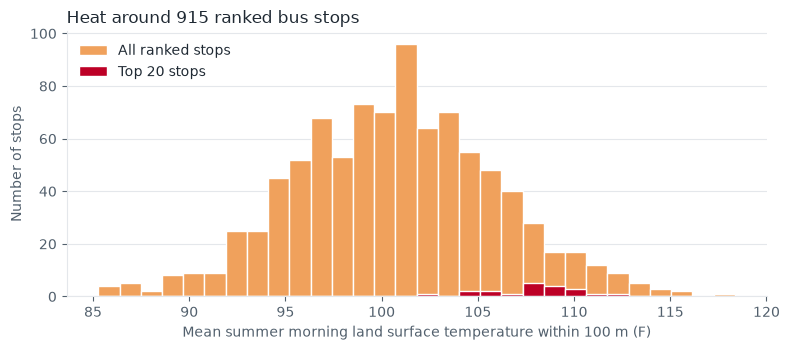

top 20 heat range: 102.8 to 112.2 F, county stop median 100.8 F


In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6))
temps_f = ranked["mean_lst_f"]
bins = np.linspace(temps_f.min(), temps_f.max(), 31)
ax.hist(temps_f, bins=bins, color=BAR, edgecolor="white", linewidth=1, label="All ranked stops")
lo, hi = ranked.loc[ranked["rank"] <= 20, "mean_lst_f"].agg(["min", "max"])
top_temps = ranked.loc[ranked["rank"] <= 20, "mean_lst_f"]
ax.hist(top_temps, bins=bins, color=BAR_TOP, edgecolor="white", linewidth=1, label="Top 20 stops")
ax.set_xlabel("Mean summer morning land surface temperature within 100 m (F)")
ax.set_ylabel("Number of stops")
ax.set_title(f"Heat around {len(ranked)} ranked bus stops", loc="left", fontsize=12, color=INK)
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
print(f"top 20 heat range: {lo:.1f} to {hi:.1f} F, county stop median {temps_f.median():.1f} F")

**Score for the top 20.** Each bar is one stop's score. Some names repeat, for example the
Southwest Recreation Center has three separate stops in the top 20 (different stop IDs).

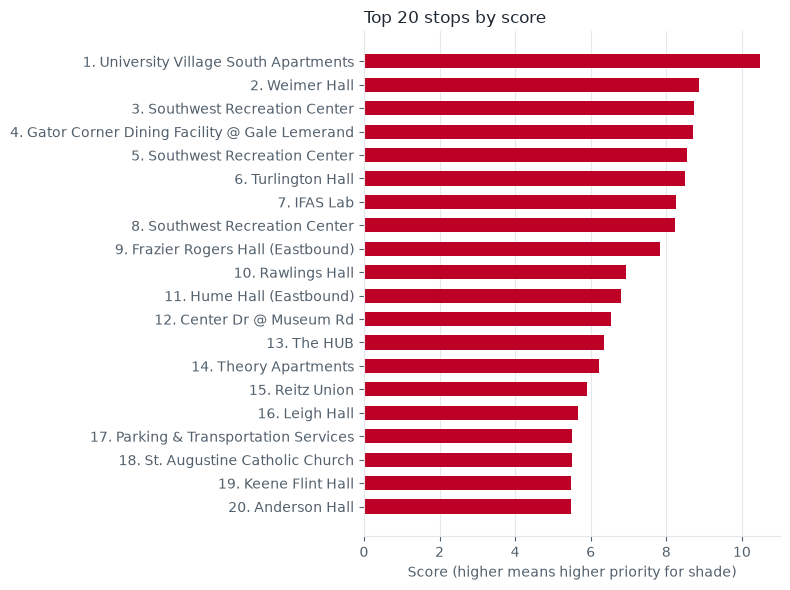

In [9]:
t = ranked[ranked["rank"] <= 20].sort_values("rank", ascending=False)
labels = [f'{int(r)}. {n[:48]}' for r, n in zip(t["rank"], t["stop_name"])]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, t["score"], color=BAR_TOP, height=0.6)
ax.set_xlabel("Score (higher means higher priority for shade)")
ax.set_title("Top 20 stops by score", loc="left", fontsize=12, color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 6. How the top 20 compares with all ranked stops

This table checks what is driving the top of the list, since a judge may ask why stop 1 is first.

In [10]:
top_mask = ranked["rank"] <= 20
comp = pd.DataFrame({
    "top 20": [
        ranked.loc[top_mask, "mean_lst_f"].median(),
        ranked.loc[top_mask, "daily_trips"].median(),
        (ranked.loc[top_mask, "shelter_status"] == "none").mean() * 100,
        (ranked.loc[top_mask, "shelter_status"] == "sheltered").mean() * 100,
        ranked.loc[top_mask, "pct_no_vehicle"].median(),
    ],
    "all ranked": [
        ranked["mean_lst_f"].median(),
        ranked["daily_trips"].median(),
        (ranked["shelter_status"] == "none").mean() * 100,
        (ranked["shelter_status"] == "sheltered").mean() * 100,
        ranked["pct_no_vehicle"].median(),
    ],
}, index=[
    "median temperature (F)", "median bus visits per weekday", "% with no shelter (OSM)",
    "% sheltered (OSM)", "median % households with no vehicle in tract",
]).round(1)
comp

,top 20,all ranked
median temperature (F),108.3,100.8
median bus visits per weekday,158.0,25.0
% with no shelter (OSM),70.0,51.5
% sheltered (OSM),10.0,11.0
median % households with no vehicle in tract,30.5,12.6


In [11]:
# stops with the same name in the top 20 and where the top 20 sit
print("distinct stop names in top 20:", top20["stop_name"].nunique(), "of 20")
print("tracts represented in top 20: ", ranked.loc[top_mask, "tract_geoid"].nunique())

distinct stop names in top 20: 18 of 20
tracts represented in top 20:  3


## 7. Vegetation and heat (EMERGE Textbook 1, Chapter 4)

The EMERGE lesson *Temperature, Rainfall & Vegetation* maps land surface temperature and NDVI (a vegetation
index computed from Sentinel-2 as `(NIR - Red) / (NIR + Red)`) side by side for Florida. We do the same
kind of comparison at the scale of a bus stop: for each stop, the median NDVI within 100 m
(`outputs/stop_canopy.csv`, Sentinel-2 L2A, summer 2026) next to the Landsat land surface temperature
in the same 100 m circle.

What is from the lesson and what is ours: the NDVI formula and the idea of viewing temperature and
vegetation together come from the lesson. The lesson does not state a relationship between them and gives
no NDVI cutoffs. The relationship below is our own result, and `pct_green` (the share of pixels with
NDVI above 0.4) is our own choice of cutoff. We use Landsat and Planetary Computer, not the lesson's MODIS
and Google Earth Engine, and we leave out rainfall.

In [12]:
canopy = pd.read_csv(ROOT / "outputs" / "stop_canopy.csv", dtype={"stop_id": str},
                     usecols=["stop_id", "mean_ndvi", "pct_green"])
veg = df.merge(canopy, on="stop_id", how="left", validate="one_to_one")
veg = veg[veg["pixel_count"].fillna(0).gt(0) & veg["mean_lst_c"].notna()].copy()
veg["mean_lst_f"] = veg["mean_lst_c"] * 9 / 5 + 32
print(f"stops with both temperature and NDVI: {len(veg)} of {len(df)}")
assert veg["mean_ndvi"].notna().all() and veg["mean_ndvi"].between(-1, 1).all()

pearson = veg["mean_ndvi"].corr(veg["mean_lst_c"])
spearman = veg["mean_ndvi"].rank().corr(veg["mean_lst_c"].rank())
slope_c_per_tenth = np.polyfit(veg["mean_ndvi"], veg["mean_lst_c"], 1)[0] * 0.1
print(f"correlation of NDVI with temperature: Pearson {pearson:.2f}, Spearman {spearman:.2f}")
print(f"each +0.1 NDVI goes with {slope_c_per_tenth:.2f} C ({slope_c_per_tenth * 9 / 5:.2f} F) in stop temperature")

stops with both temperature and NDVI: 929 of 971
correlation of NDVI with temperature: Pearson -0.55, Spearman -0.55
each +0.1 NDVI goes with -1.22 C (-2.20 F) in stop temperature


In [13]:
fifths = pd.qcut(veg["mean_ndvi"], 5, labels=["1 least green", "2", "3", "4", "5 greenest"])
by = veg.groupby(fifths, observed=True).agg(
    stops=("stop_id", "size"), mean_ndvi=("mean_ndvi", "mean"),
    percent_green=("pct_green", "mean"), temp_f=("mean_lst_f", "mean")).round(2)
display(by)
gap_f = by["temp_f"].iloc[0] - by["temp_f"].iloc[-1]
print(f"stops in the least green fifth average {gap_f:.1f} F hotter than the greenest fifth "
      f"({by['temp_f'].iloc[0]:.1f} F vs {by['temp_f'].iloc[-1]:.1f} F, summer mornings)")

,stops,mean_ndvi,percent_green,temp_f
mean_ndvi,,,,
1 least green,186,0.24,20.75,104.22
2,188,0.37,43.85,102.99
3,185,0.46,59.65,101.07
4,185,0.52,70.46,99.35
5 greenest,185,0.61,83.11,96.01


stops in the least green fifth average 8.2 F hotter than the greenest fifth (104.2 F vs 96.0 F, summer mornings)


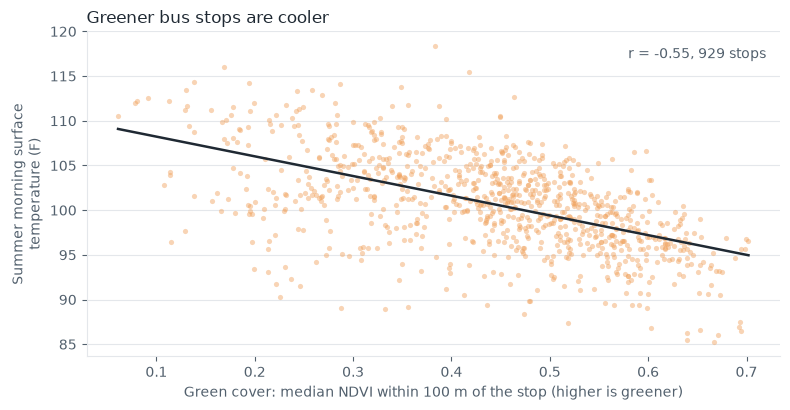

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(veg["mean_ndvi"], veg["mean_lst_f"], s=14, color=BAR, alpha=0.45, linewidths=0)
b1, b0 = np.polyfit(veg["mean_ndvi"], veg["mean_lst_f"], 1)
xs = np.array([veg["mean_ndvi"].min(), veg["mean_ndvi"].max()])
ax.plot(xs, b0 + b1 * xs, color=INK, linewidth=1.8)
ax.set_xlabel("Green cover: median NDVI within 100 m of the stop (higher is greener)")
ax.set_ylabel("Summer morning surface\ntemperature (F)")
ax.set_title("Greener bus stops are cooler", loc="left", fontsize=12, color=INK)
ax.text(0.98, 0.95, f"r = {pearson:.2f}, {len(veg)} stops", transform=ax.transAxes,
        ha="right", va="top", color=MUTED)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Reading this carefully.** The two datasets agree: stops with more vegetation around them are cooler, which
is a useful cross-check on both layers. It is a correlation, not proof that adding plants would cool a
stop by that amount. Temperature is a morning satellite surface reading, NDVI is a summer median from a
different satellite, and nearby stops share pixels, so the 929 points are not fully independent.

**Where vegetation enters our rankings.** The main stop score does not use it. The separate "needs shade
most" list does, as `(1 - green cover)`, a rough stand-in for bare surroundings.

In [15]:
need = pd.read_csv(ROOT / "outputs" / "shade_need.csv", dtype={"stop_id": str})
top_need = need[need["top20_shade_need"]]
print(f"average green cover within 100 m: needs-shade-most top 20 = {top_need['pct_green'].mean():.0f}%, "
      f"all {len(need)} eligible stops = {need['pct_green'].mean():.0f}%")

average green cover within 100 m: needs-shade-most top 20 = 21%, all 814 eligible stops = 57%


## 8. The map

The default map page is the app view (`docs/app.html`), published at https://jonathankash.github.io/ShadeMap/.
Stops are colored by priority for shade and sized by weekday buses, the 20 stops on the "needs shade most"
list are black, and a side panel shows each stop's details and rider photos. The screenshot below is that view.
The older classic map (`docs/classic.html`) shows the same ranking with numbered pins for the top 20.

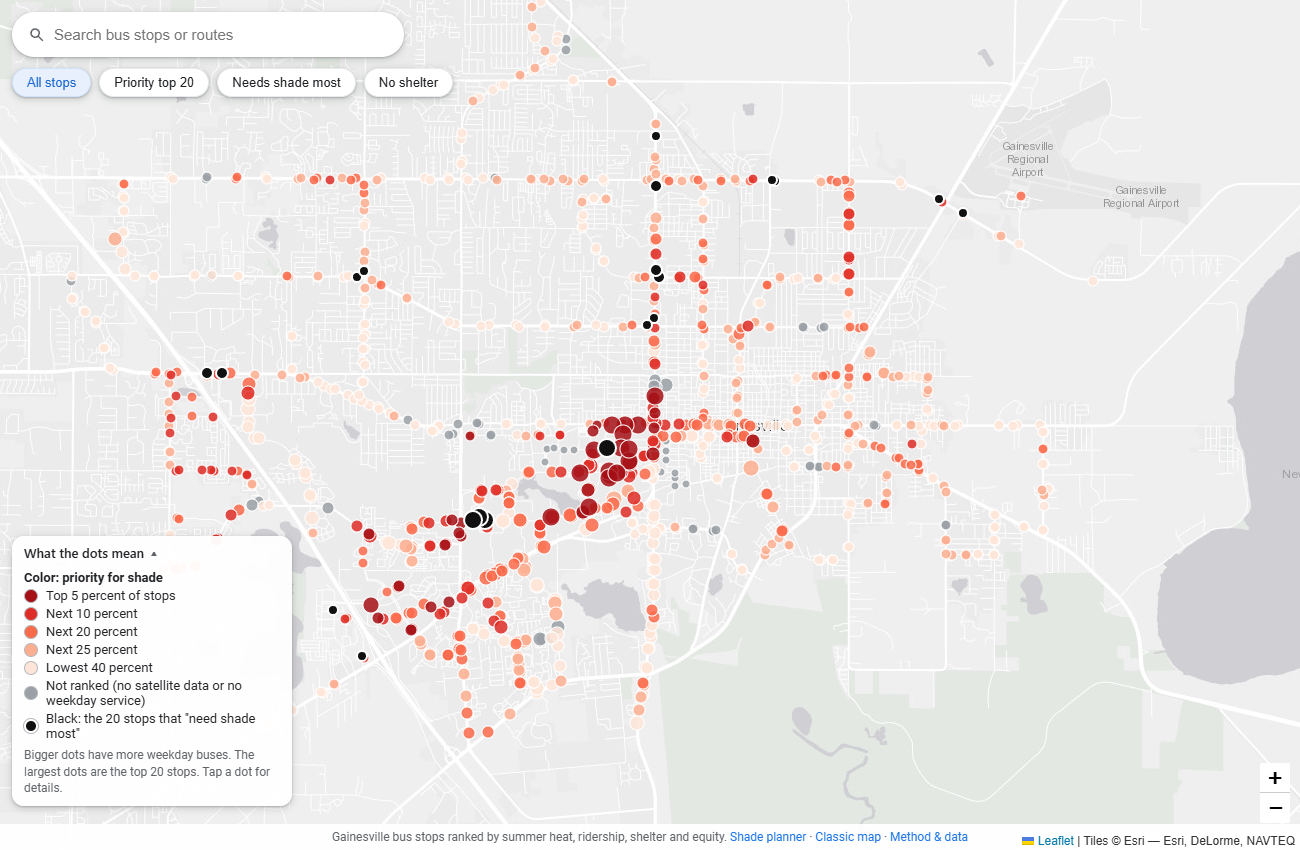

In [16]:
display(Image(filename=str(ROOT / "assets" / "map.png"), width=900))

## Limitations

Stated in full in the README. In short: OpenStreetMap shelter coverage is partial, bus visits are a
ridership proxy, Landsat temperatures are morning values from one summer, 30 m pixels blur a stop with
its surroundings, 42 stops have no temperature data, census values are tract level, and shade itself is
not measured.